In [1]:
import os
import sys

import numpy as np

In [2]:
sys.path.append(os.path.join(os.getenv("CVF_PROJECT_DIR", ""), "cvf-analysis"))

utils_path = os.path.join(os.getenv("CVF_PROJECT_DIR", ""), "utils")
sys.path.append(utils_path)

from plot_graphs import plot
from command_line_helpers import get_graph

In [3]:
graph_name = "graph_16"
_, graph = next(get_graph([graph_name]))
graph

{0: {1},
 1: {0, 2, 3},
 2: {1},
 3: {1, 4, 5},
 4: {3},
 5: {3, 6, 7},
 6: {5},
 7: {5}}

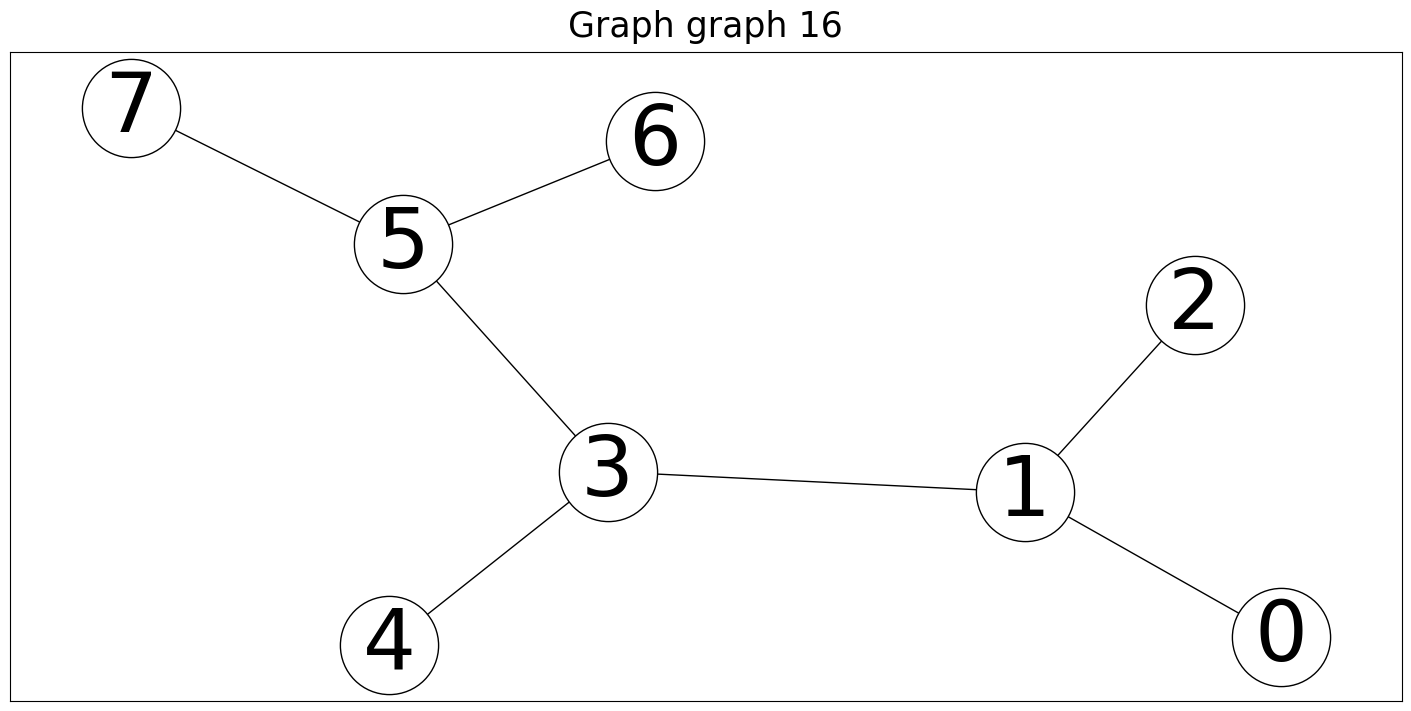

In [4]:
plot([graph_name])

$PR(P_i) = \frac{1 - d}{N} + d \sum_{P_j \in M(P_i)} \frac{PR(P_j)}{L(P_j)}$


In [5]:
d = 0.85
tol = 1e-10

In [6]:
N = len(graph)
print("No. of nodes:", N)

No. of nodes: 8


# Initial PR values

In [7]:
PR = np.full(N, 1/N)
PR

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

# Iterations

In [8]:
itr = 1
while True:
    PR_new = []
    converged = True
    for n in range(N):
        temp = (1-d)/N + d * np.sum([ PR[nbr]/len(graph[nbr]) for nbr in graph[n] ])
        PR_new.append(temp)
        if abs(temp - PR[n]) > tol:
            converged = False
    PR = np.array(PR_new)
    if converged:
        print("Converged on the Iteration:", itr)
        break
    itr += 1


Converged on the Iteration: 128


# Page Rank scores

In [9]:
PR

array([0.07745005, 0.20717665, 0.07745005, 0.20033493, 0.07551156,
       0.20717665, 0.07745005, 0.07745005])

# Sorted Page Rank Scores

In [10]:
dict(sorted(enumerate(PR), key=lambda x: x[1], reverse=True))

{1: np.float64(0.20717665046339956),
 5: np.float64(0.20717665046339956),
 3: np.float64(0.20033493127055152),
 0: np.float64(0.07745005099267666),
 2: np.float64(0.07745005099267666),
 6: np.float64(0.07745005099267666),
 7: np.float64(0.07745005099267666),
 4: np.float64(0.0755115638319428)}